In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None


In [5]:
test = pd.read_csv('/kaggle/input/playground-series-s3e25/test.csv')
test.head()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average
0,10407,884.0,121.420000,35.36,5.28,82.561240,9.370384,2.298,1.9072,1.200000,0.461899,1.79459
1,10408,90.0,9.931960,18.00,5.60,39.568056,12.086300,2.868,1.6520,0.864000,0.476196,1.41194
2,10409,116.0,7.767992,11.60,4.80,23.231818,11.023840,2.644,1.7940,0.960000,0.499514,0.78834
3,10410,100.0,9.107996,10.00,4.80,20.298893,12.086300,2.828,1.6620,0.792000,0.495796,1.20466
4,10411,55.0,4.030000,11.00,4.00,22.977675,11.280950,2.455,1.7500,0.893333,0.476095,0.93456


In [6]:
train = pd.read_csv('/kaggle/input/playground-series-s3e25/train.csv')
train.head()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,10.0,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,10.0,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,15.6,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,10.0,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,11.6,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0


In [7]:
combined = pd.concat([train,test])
combined.head()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,10.0,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,10.0,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,15.6,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,10.0,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,11.6,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0


In [8]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17346 entries, 0 to 6938
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     17346 non-null  int64  
 1   allelectrons_Total     17346 non-null  float64
 2   density_Total          17346 non-null  float64
 3   allelectrons_Average   17346 non-null  float64
 4   val_e_Average          17346 non-null  float64
 5   atomicweight_Average   17346 non-null  float64
 6   ionenergy_Average      17346 non-null  float64
 7   el_neg_chi_Average     17346 non-null  float64
 8   R_vdw_element_Average  17346 non-null  float64
 9   R_cov_element_Average  17346 non-null  float64
 10  zaratio_Average        17346 non-null  float64
 11  density_Average        17346 non-null  float64
 12  Hardness               10407 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 1.9 MB


In [10]:
combined.dtypes

id                         int64
allelectrons_Total       float64
density_Total            float64
allelectrons_Average     float64
val_e_Average            float64
atomicweight_Average     float64
ionenergy_Average        float64
el_neg_chi_Average       float64
R_vdw_element_Average    float64
R_cov_element_Average    float64
zaratio_Average          float64
density_Average          float64
Hardness                 float64
dtype: object

In [12]:
combined.columns

Index(['id', 'allelectrons_Total', 'density_Total', 'allelectrons_Average',
       'val_e_Average', 'atomicweight_Average', 'ionenergy_Average',
       'el_neg_chi_Average', 'R_vdw_element_Average', 'R_cov_element_Average',
       'zaratio_Average', 'density_Average', 'Hardness'],
      dtype='object')

In [16]:
combined.skew()

id                        0.000000
allelectrons_Total       37.743057
density_Total            11.434946
allelectrons_Average      1.670323
val_e_Average            -2.261651
atomicweight_Average      1.804872
ionenergy_Average        -3.457851
el_neg_chi_Average       -3.374367
R_vdw_element_Average    -4.636759
R_cov_element_Average    -0.520177
zaratio_Average          -1.444336
density_Average           1.637701
Hardness                 -0.125749
dtype: float64

In [17]:
combined.kurt()

id                         -1.200000
allelectrons_Total       2122.322539
density_Total             298.938094
allelectrons_Average        2.727917
val_e_Average              11.998847
atomicweight_Average        3.306650
ionenergy_Average          24.199499
el_neg_chi_Average         21.609289
R_vdw_element_Average      40.744647
R_cov_element_Average       5.122347
zaratio_Average            25.890345
density_Average             2.296333
Hardness                   -0.793775
dtype: float64

In [19]:
combined.isnull().sum()/len('combined'*100)

id                       0.00000
allelectrons_Total       0.00000
density_Total            0.00000
allelectrons_Average     0.00000
val_e_Average            0.00000
atomicweight_Average     0.00000
ionenergy_Average        0.00000
el_neg_chi_Average       0.00000
R_vdw_element_Average    0.00000
R_cov_element_Average    0.00000
zaratio_Average          0.00000
density_Average          0.00000
Hardness                 8.67375
dtype: float64

In [21]:
combined.shape

(17346, 13)

In [23]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

id                       8672.500000
allelectrons_Total         62.000000
density_Total               9.118508
allelectrons_Average       12.000000
val_e_Average               0.800000
atomicweight_Average       28.420607
ionenergy_Average           1.069828
el_neg_chi_Average          0.276563
R_vdw_element_Average       0.140833
R_cov_element_Average       0.118333
zaratio_Average             0.019975
density_Average             1.966720
Hardness                    3.000000
dtype: float64


In [24]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [25]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

In [27]:
combined_new.shape

(10968, 13)

In [28]:
cat_cols = combined.select_dtypes(include='object')

In [29]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

In [31]:
num_cols = combined.select_dtypes(include='number')

In [32]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

id
__________________________________________________
allelectrons_Total
__________________________________________________
density_Total
__________________________________________________
allelectrons_Average
__________________________________________________
val_e_Average
__________________________________________________
atomicweight_Average
__________________________________________________
ionenergy_Average
__________________________________________________
el_neg_chi_Average
__________________________________________________
R_vdw_element_Average
__________________________________________________
R_cov_element_Average
__________________________________________________
zaratio_Average
__________________________________________________
density_Average
__________________________________________________
Hardness
__________________________________________________


In [39]:
x=1
plt.figure(figsize=(5,5))
for i in cat_cols:
    sns.barplot(data=combined,kde=True,axis=1)
    print(i)
    print('\n')
    plt.show()


<Figure size 500x500 with 0 Axes>

id




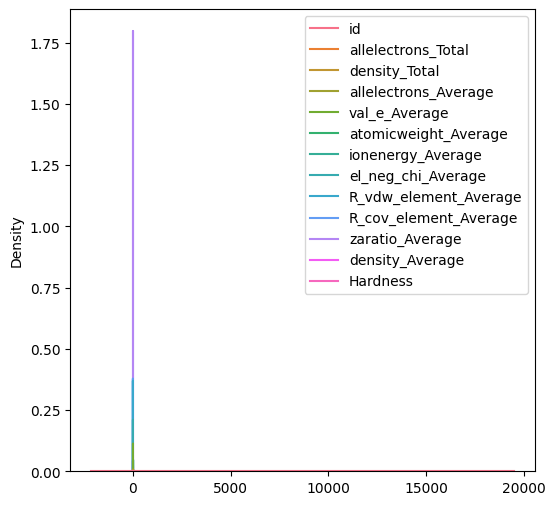

allelectrons_Total




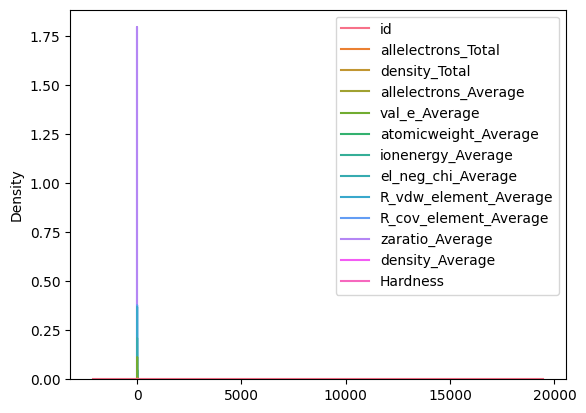

density_Total




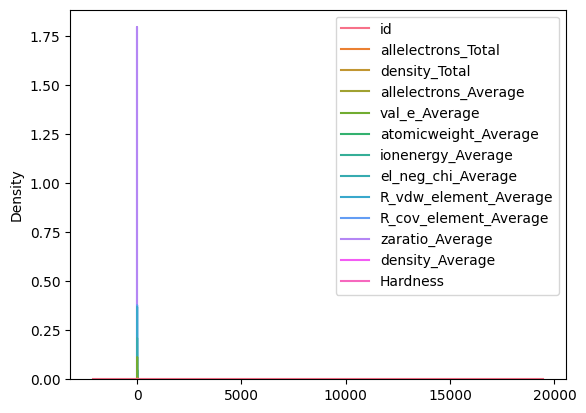

allelectrons_Average




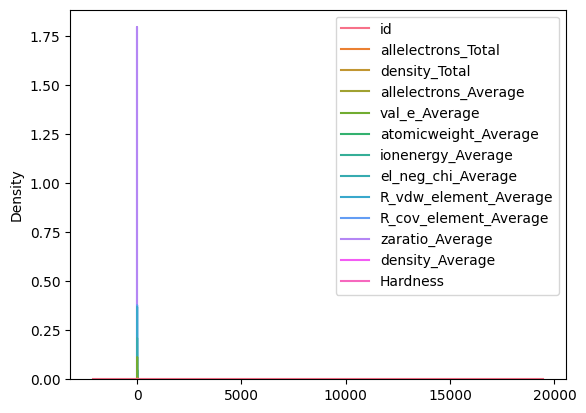

val_e_Average




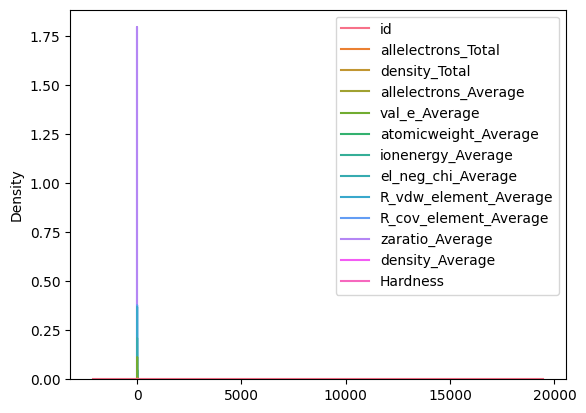

atomicweight_Average




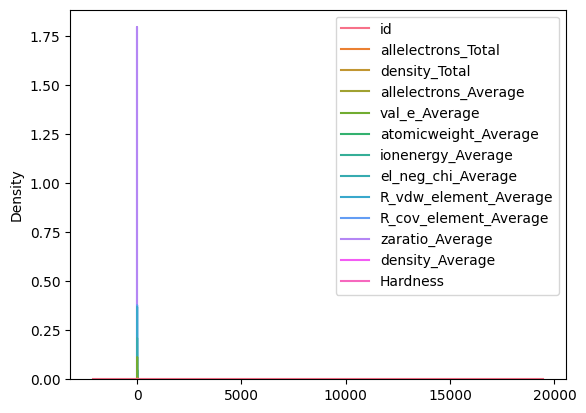

ionenergy_Average




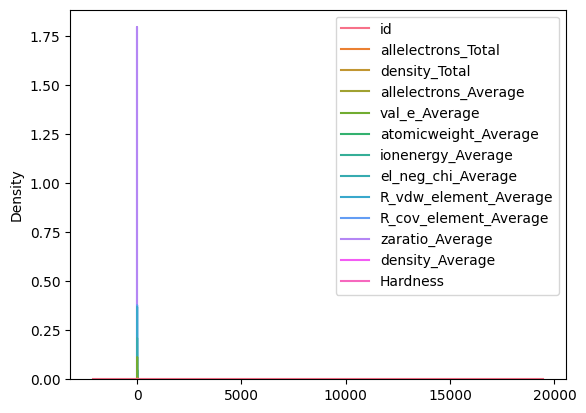

el_neg_chi_Average




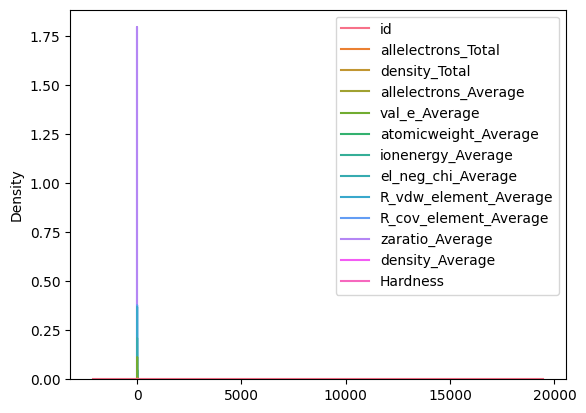

R_vdw_element_Average




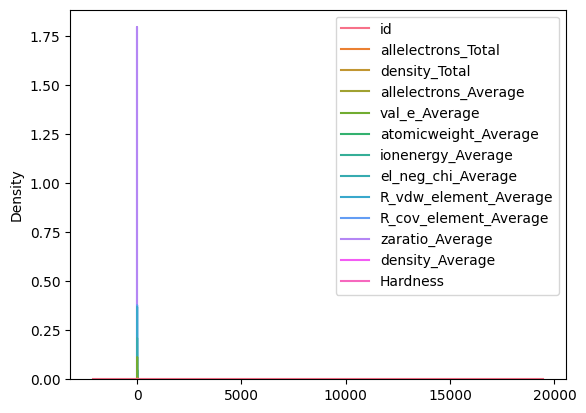

R_cov_element_Average




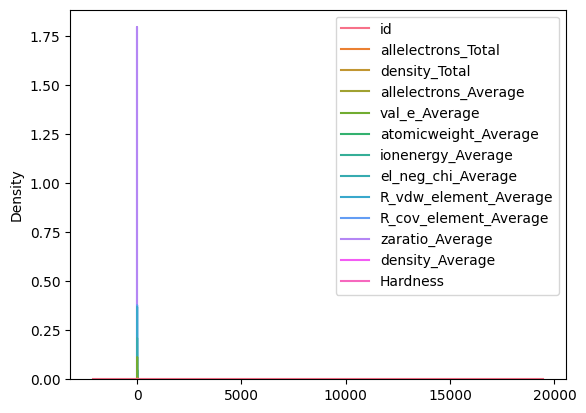

zaratio_Average




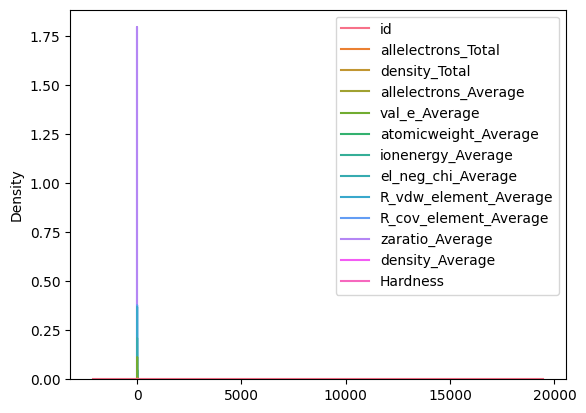

density_Average




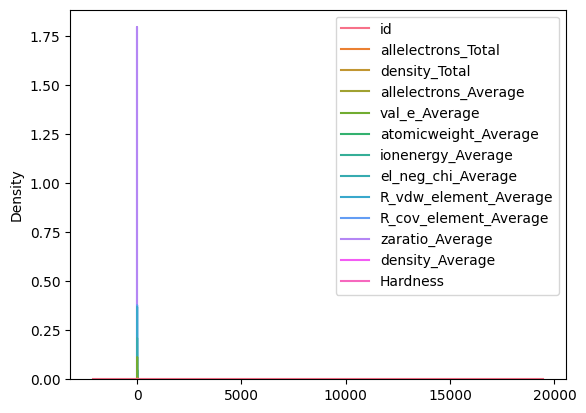

Hardness




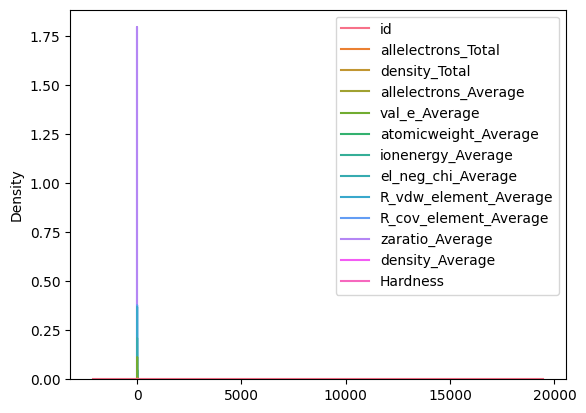

In [42]:
x=1
plt.figure(figsize=(6,6))
for i in num_cols:
    sns.kdeplot(data=combined)
    print(i)
    print('\n')
    plt.show()

<Axes: >

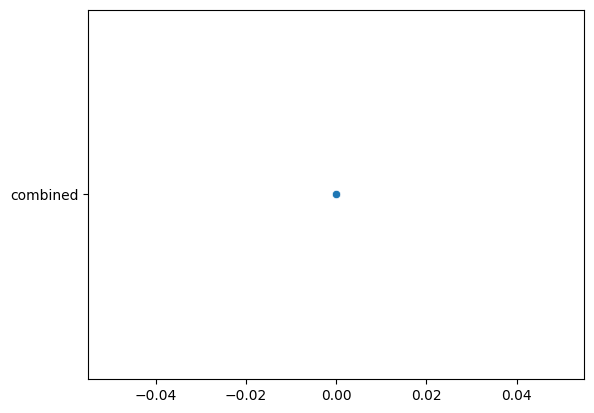

In [46]:
sns.scatterplot('combined')

<Axes: >

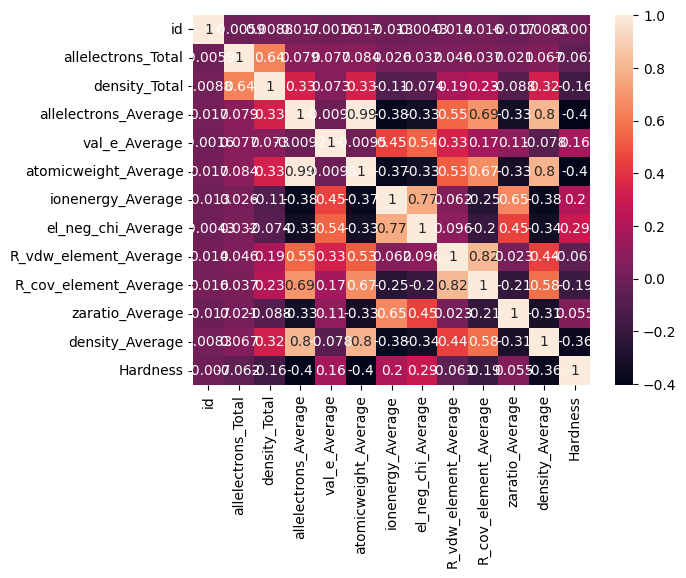

In [53]:
sns.heatmap(combined.corr(),annot=True)

<Axes: >

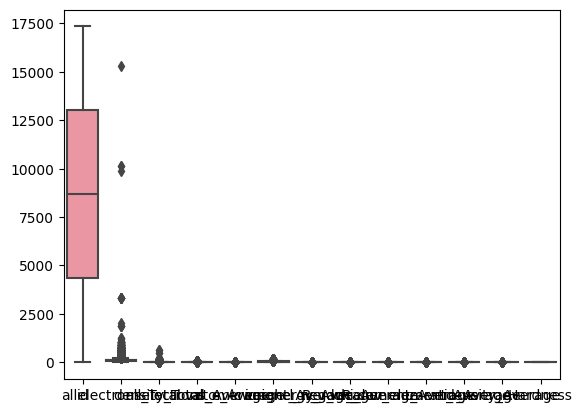

In [54]:
sns.boxplot(combined)

<Axes: >

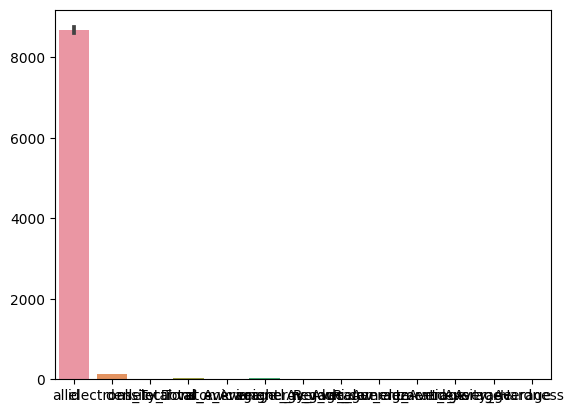

In [55]:
sns.barplot(combined)

<Axes: >

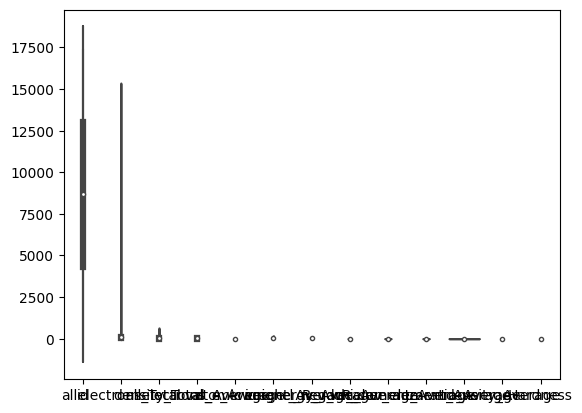

In [56]:
sns.violinplot(combined)

<Axes: ylabel='Density'>

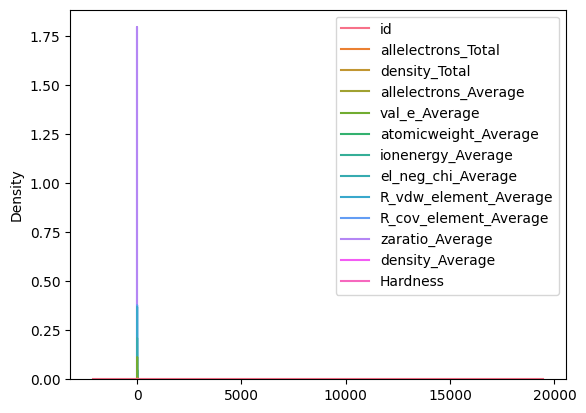

In [57]:
sns.kdeplot(combined)

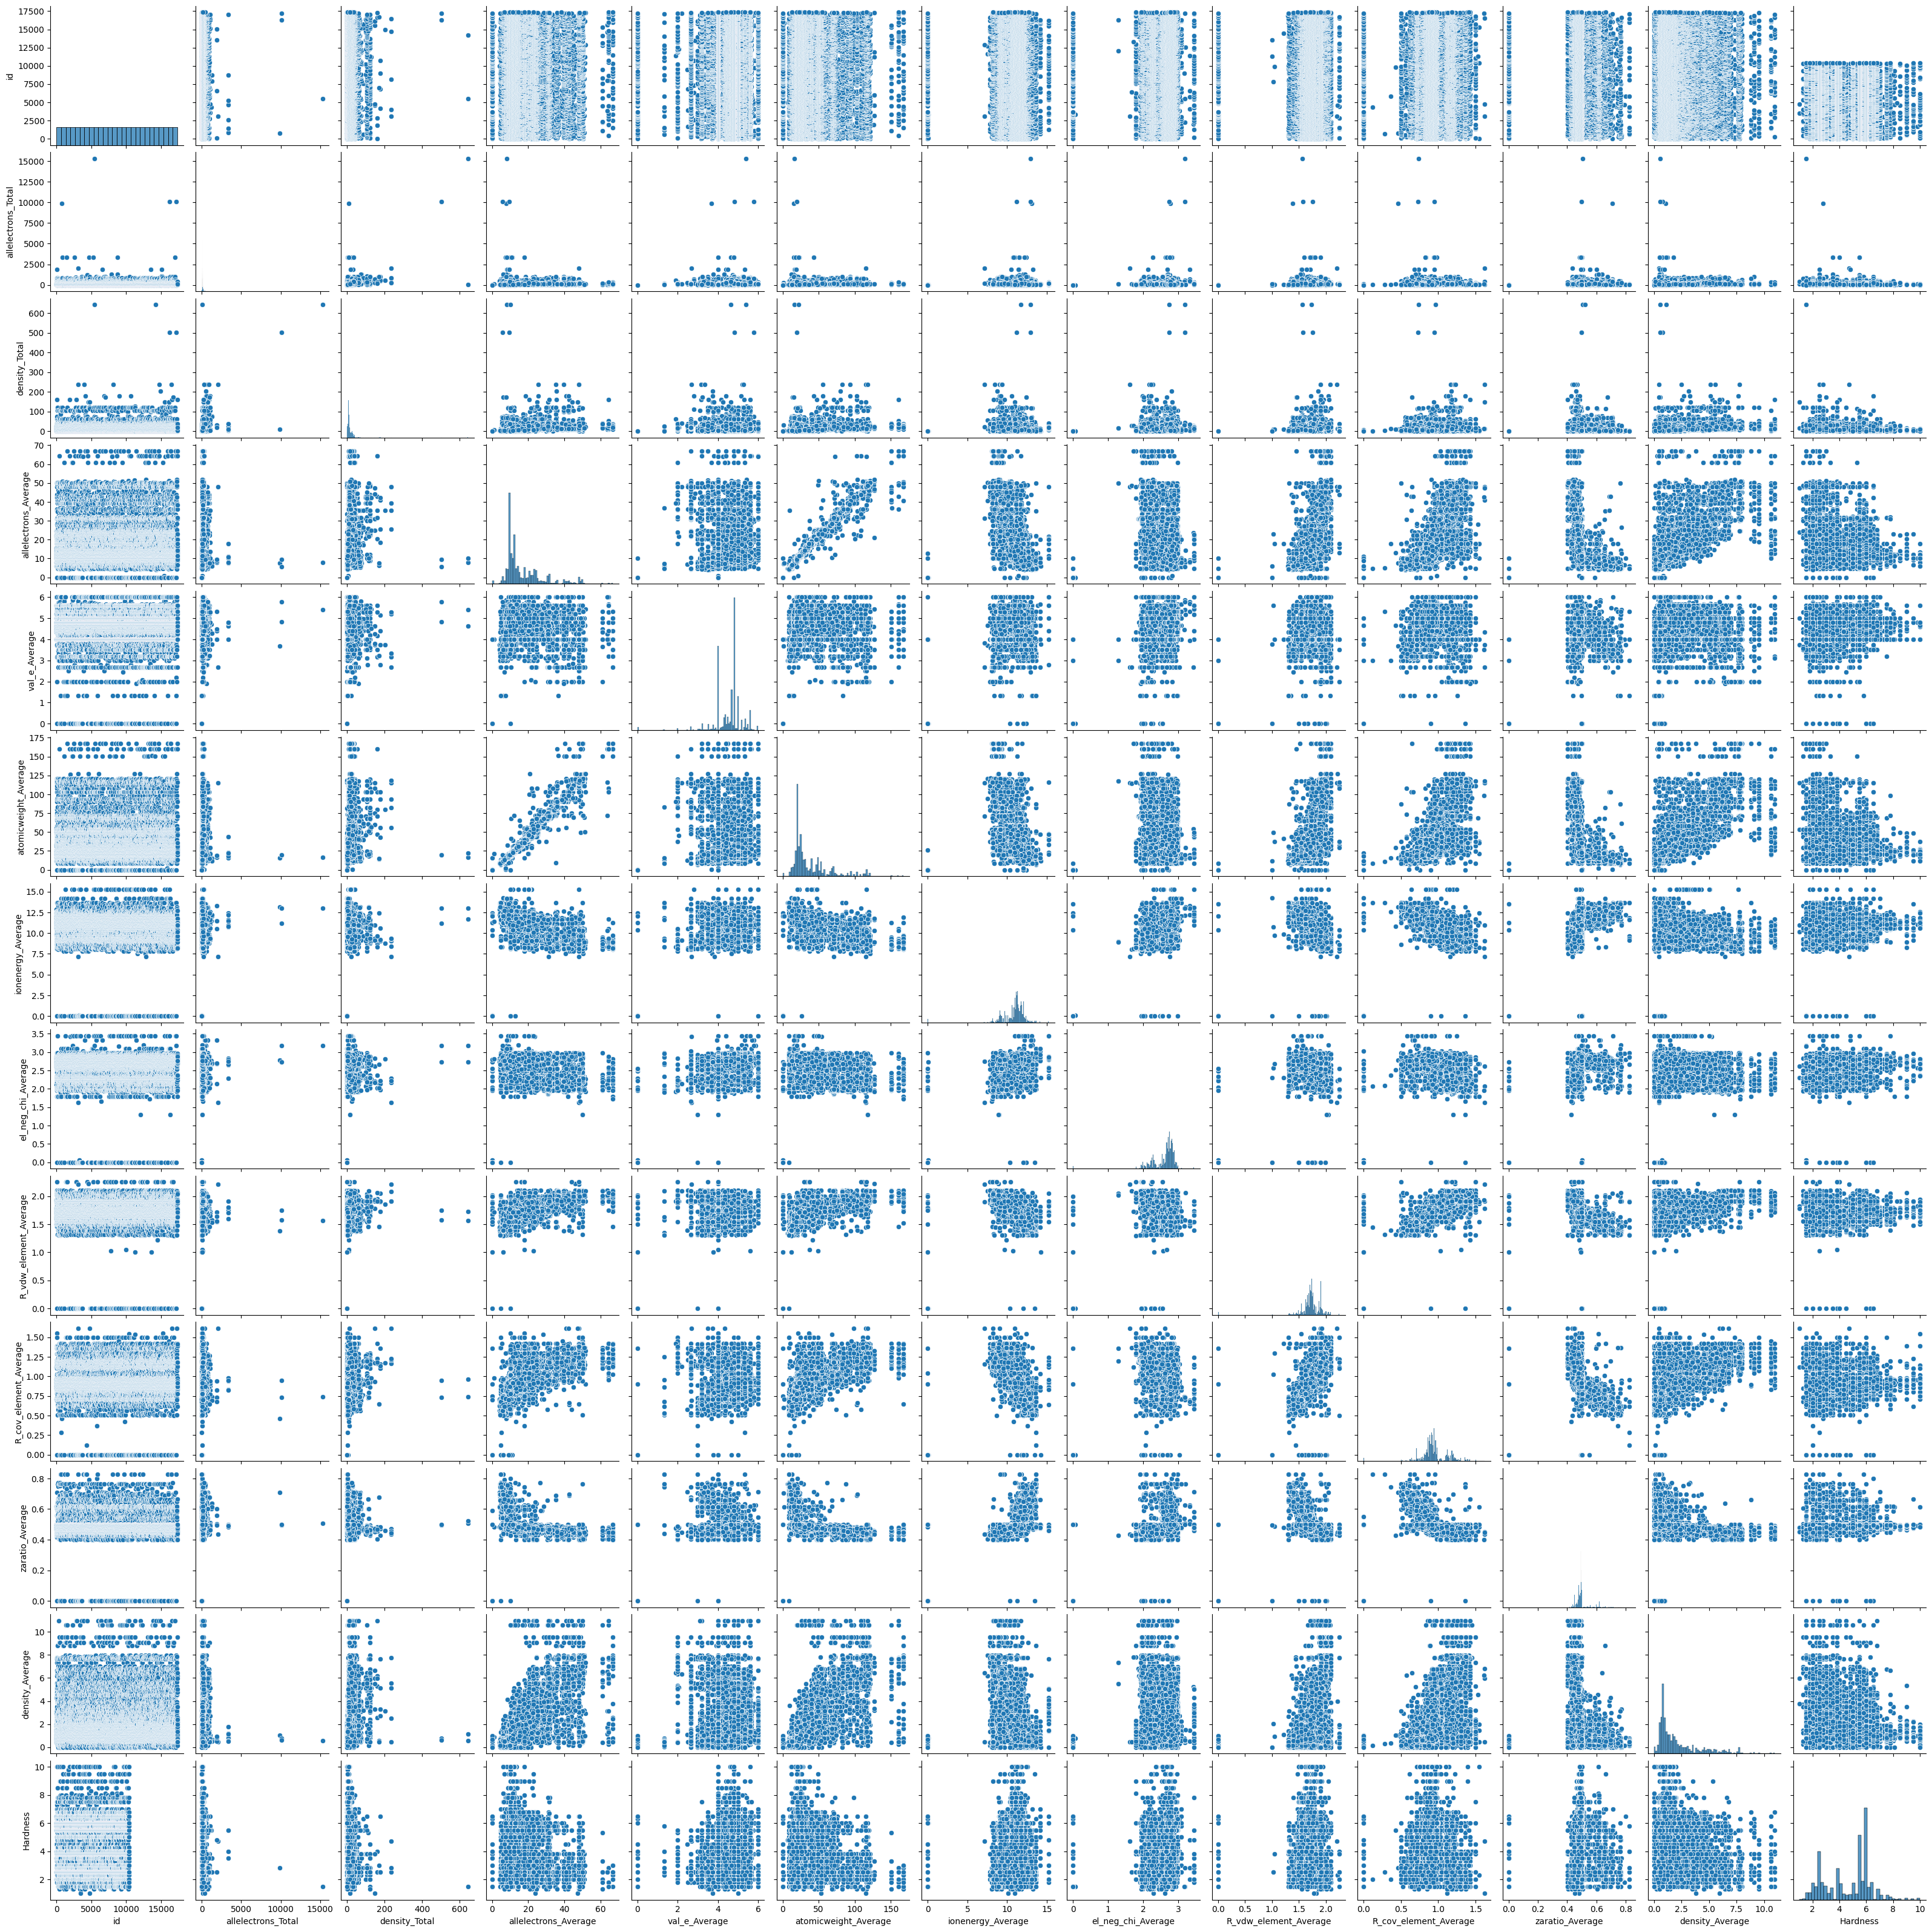

In [60]:
sns.pairplot(combined)

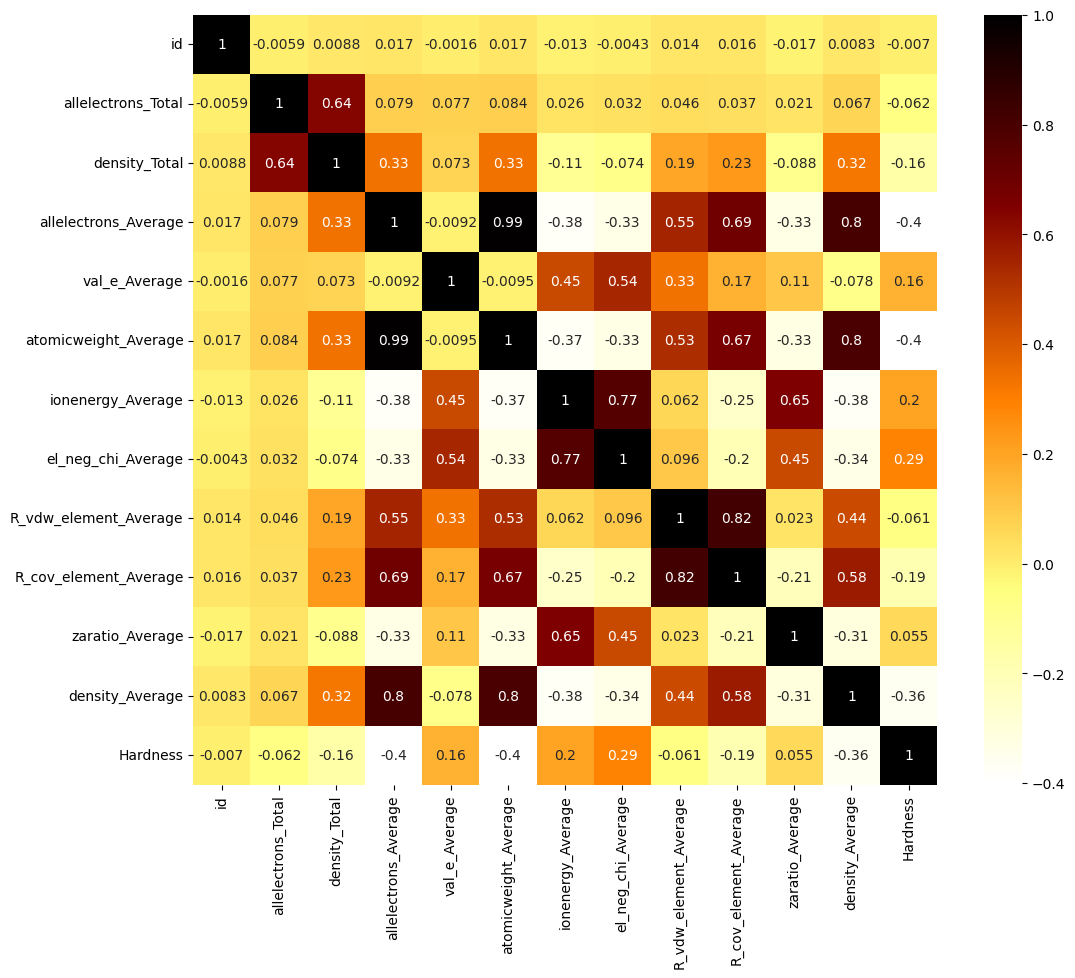

In [63]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

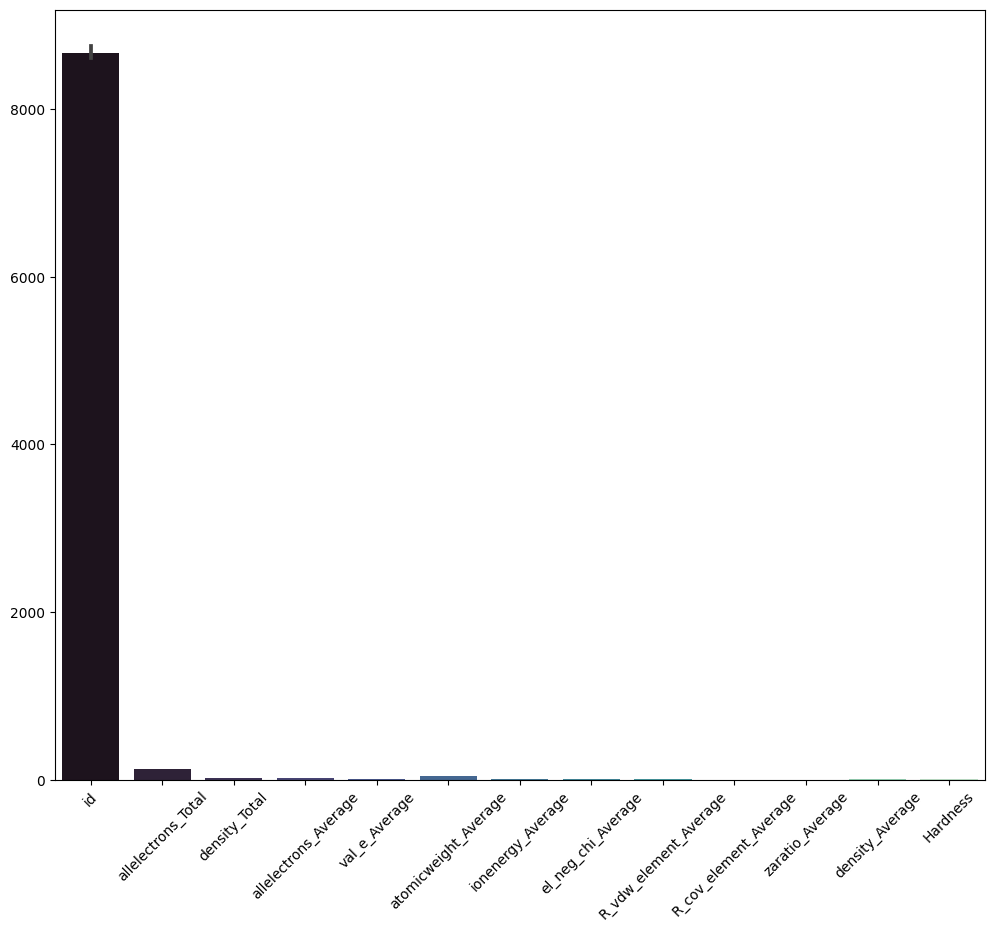

In [65]:
plt.figure(figsize=(12,10))
sns.barplot(combined,palette='mako');
plt.xticks(rotation=45);

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


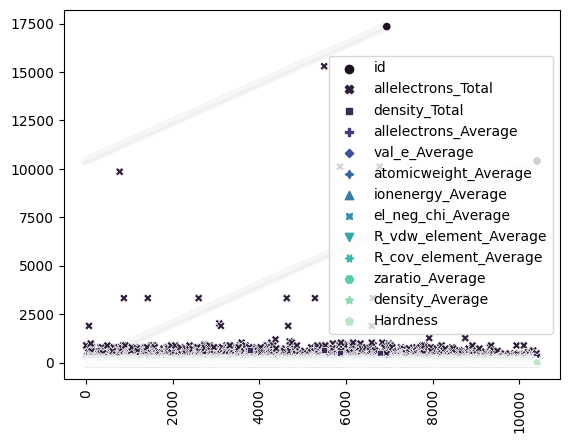

In [66]:
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation=90);

(array([-5000.,     0.,  5000., 10000., 15000., 20000., 25000.]),
 [Text(-5000.0, 0, '−5000'),
  Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000')])

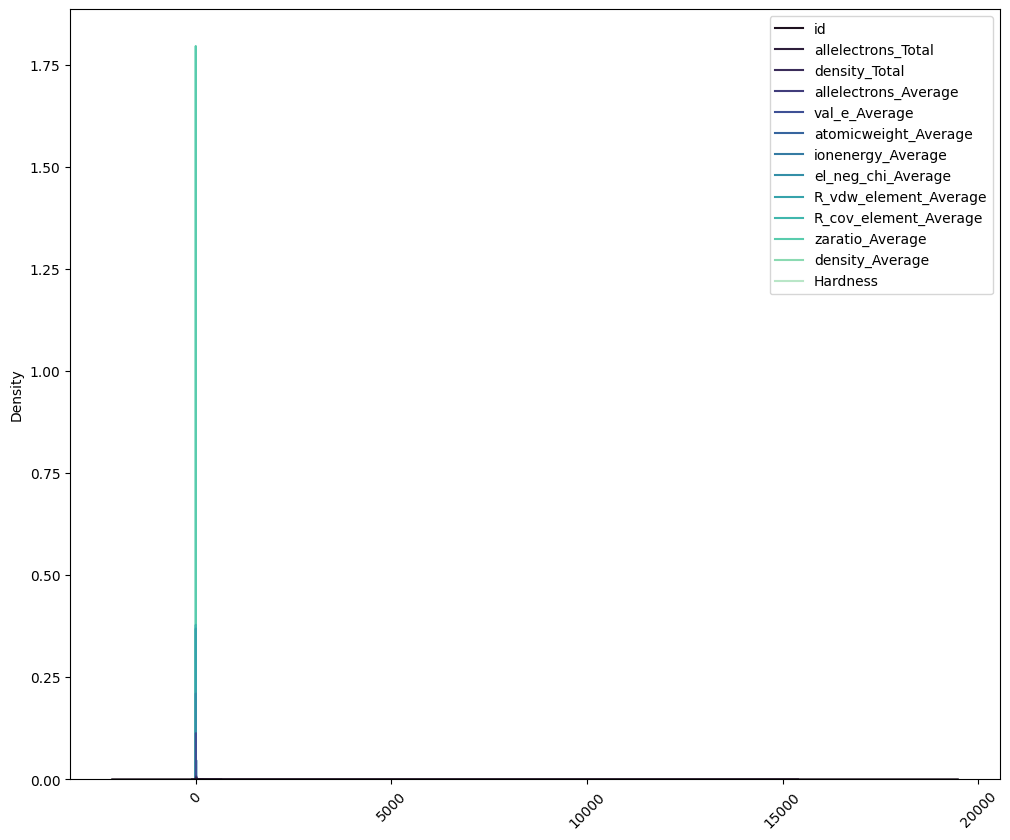

In [67]:
plt.figure(figsize=(12,10))
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=45)

In [78]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,17346.0,8672.500000,5007.503220,0.0,4336.250000,8672.500000,13008.750000,17345.000000
allelectrons_Total,17346.0,127.416105,217.646048,0.0,68.000000,100.000000,130.000000,15300.000000
density_Total,17346.0,14.612423,17.240077,0.0,7.558488,10.650000,16.676996,643.093804
allelectrons_Average,17346.0,17.182421,10.684067,0.0,10.000000,12.600000,22.000000,67.000000
val_e_Average,17346.0,4.546814,0.687772,0.0,4.000000,4.727273,4.800000,6.000000
atomicweight_Average,17346.0,37.873769,26.556198,0.0,20.298893,26.203827,48.719500,167.400000
ionenergy_Average,17346.0,10.931589,1.396615,0.0,10.590660,11.202760,11.660488,15.245810
el_neg_chi_Average,17346.0,2.607845,0.330136,0.0,2.528437,2.706000,2.805000,3.443000
R_vdw_element_Average,17346.0,1.733961,0.191746,0.0,1.672500,1.736000,1.813333,2.250000
R_cov_element_Average,17346.0,0.946335,0.179732,0.0,0.865000,0.918333,0.983333,1.615840


In [74]:
combined.tail()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
6934,17341,446.0,36.135392,9.636364,4.636364,19.689448,11.045515,2.768636,1.769697,0.871818,0.498702,0.11548,NaN
6935,17342,36.0,3.550000,18.000000,4.000000,36.068500,8.236600,1.790000,2.055000,1.390000,0.499000,1.35045,NaN
6936,17343,68.0,4.545328,11.333333,5.333333,22.688853,10.938358,2.876667,1.713333,0.916667,0.499074,0.73425,NaN
6937,17344,40.0,2.334164,6.666667,4.000000,13.016128,12.700467,2.770000,1.476667,0.616667,0.663797,0.51227,NaN
6938,17345,134.0,17.590000,67.000000,5.000000,167.400000,8.213150,1.950000,2.040000,1.410000,0.401635,0.44035,NaN


In [84]:
combined.head()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,10.0,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,10.0,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,15.6,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,10.0,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,11.6,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0


##### 

In [86]:
combined.iloc[5:11,2:]

,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
5,24.529328,21.833333,4.666667,50.131500,11.948200,2.858333,1.758333,0.896667,0.466388,2.94712,6.0
6,3.253996,10.000000,4.800000,20.077018,11.023840,2.727000,1.767000,0.880000,0.499010,0.80631,2.0
7,2.701748,6.000000,4.000000,11.663548,12.415840,2.766000,1.495000,0.710000,0.618493,0.41631,4.0
8,14.632000,12.000000,4.800000,24.808518,11.331820,2.870000,1.718500,0.910000,0.492736,1.96268,6.0
9,13.477328,12.812500,5.000000,24.988133,11.037175,2.818750,1.601250,0.881250,0.493192,1.10889,5.8
10,6.697992,8.000000,4.600000,16.862138,11.798860,2.648000,1.626000,0.912000,0.498984,0.74322,6.0


In [94]:
combined.head()

,id,allelectrons_Total,density_Total,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0


In [98]:
combined.drop([5,6,7],axis=0)

,id,allelectrons_Total,density_Total,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,4.800000,20.612526,11.088100,2.766000,1.732000,0.860000,0.496070,0.91457,6.0
1,1,100.0,7.558488,4.800000,20.298893,12.040830,2.755000,1.631000,0.910000,0.492719,0.71760,6.5
2,2,76.0,8.885992,5.600000,33.739258,12.086300,2.828000,1.788000,0.864000,0.481478,1.50633,2.5
3,3,100.0,8.795296,4.800000,20.213349,10.948500,2.648000,1.626000,0.936000,0.489272,0.78937,6.0
4,4,116.0,9.577996,4.800000,24.988133,11.824480,2.766000,1.682000,0.896000,0.492736,1.86481,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6934,17341,446.0,36.135392,4.636364,19.689448,11.045515,2.768636,1.769697,0.871818,0.498702,0.11548,NaN
6935,17342,36.0,3.550000,4.000000,36.068500,8.236600,1.790000,2.055000,1.390000,0.499000,1.35045,NaN
6936,17343,68.0,4.545328,5.333333,22.688853,10.938358,2.876667,1.713333,0.916667,0.499074,0.73425,NaN
6937,17344,40.0,2.334164,4.000000,13.016128,12.700467,2.770000,1.476667,0.616667,0.663797,0.51227,NaN


In [102]:
def double_make(s):
    return s*2

In [105]:
combined[['allelectrons_Total','val_e_Average']].apply(double_make)

,allelectrons_Total,val_e_Average
0,200.0,9.600000
1,200.0,9.600000
2,152.0,11.200000
3,200.0,9.600000
4,232.0,9.600000
...,...,...
6934,892.0,9.272727
6935,72.0,8.000000
6936,136.0,10.666667
6937,80.0,8.000000


In [106]:
combined['val_e_Average'].value_counts()

val_e_Average
4.800000    4797
4.000000    3164
4.666667    1367
5.000000    1234
5.600000     742
            ... 
4.432759       1
4.466667       1
3.782273       1
5.520000       1
5.875000       1
Name: count, Length: 246, dtype: int64

In [107]:
combined.sort_values(by='val_e_Average')

,id,allelectrons_Total,density_Total,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
6503,16910,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,0.000,0.000000,0.84880,NaN
2801,13208,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,0.000,0.000000,0.94771,NaN
6397,6397,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,0.000,0.499540,0.00000,1.5
6394,6394,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,0.000,0.000000,0.81480,4.0
6375,6375,0.0,0.000000,0.0,0.000000,0.000000,2.480000,0.0000,0.000,0.000000,0.00000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...
3581,13988,88.0,11.351332,6.0,108.295515,12.027800,2.620000,1.8750,1.150,0.468330,3.11533,NaN
4080,4080,128.0,20.362000,6.0,35.457915,11.117300,2.706667,1.8400,1.150,0.489507,3.31333,6.5
10076,10076,202.0,15.266328,6.0,47.697010,12.041517,2.926667,1.7360,0.926,0.474714,2.54439,6.0
3311,3311,202.0,22.812640,6.0,47.315423,15.245810,3.443000,1.6620,0.836,0.479965,2.28126,3.0


In [108]:
combined.head()

,id,allelectrons_Total,density_Total,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0
